In [267]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import json
import os
import numpy as np
from datetime import datetime
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

In [268]:
# Configuration
SEED = 123
np.random.seed(SEED)
torch.manual_seed(SEED)

DELETE_RATIO = 0.05
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
TRAIN_EPOCHS = 10
SAVE_EPOCH = 0
RETRAIN_EPOCHS = 3
LOSS_NAME = "CrossEntropyLoss"
DATASET_TAG = "CIFAR10"
NUM_CLASSES = 10  # CIFAR-10 has 10 classes

print(f"Configuration loaded:")
print(f"  Dataset: {DATASET_TAG}")
print(f"  Seed: {SEED}")
print(f"  Delete Ratio: {DELETE_RATIO}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Train Epochs: {TRAIN_EPOCHS}")
print(f"  Save Epoch: {SAVE_EPOCH}")
print(f"  Retrain Epochs: {RETRAIN_EPOCHS}")
print(f"  Loss: {LOSS_NAME}")

Configuration loaded:
  Dataset: CIFAR10
  Seed: 123
  Delete Ratio: 0.05
  Batch Size: 64
  Learning Rate: 0.001
  Train Epochs: 10
  Save Epoch: 0
  Retrain Epochs: 3
  Loss: CrossEntropyLoss


In [269]:
# Plot saving setup (dataset + technique + seed + delete ratio)
TECHNIQUE_NAME = "first_epoch_reversal"
seed_str = f"{SEED:04d}"
delete_ratio_str = f"{DELETE_RATIO:.4f}".rstrip("0").rstrip(".").replace(".", "p")
plot_output_dir = f"../results/plots/{DATASET_TAG}_{TECHNIQUE_NAME}_seed_{seed_str}_delete_{delete_ratio_str}"
os.makedirs(plot_output_dir, exist_ok=True)


def save_plot(fig, filename):
    filepath = os.path.join(plot_output_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"Saved plot: {filepath}")


print(f"Plot directory ready: {plot_output_dir}")

Plot directory ready: ../results/plots/CIFAR10_first_epoch_reversal_seed_0123_delete_0p05


In [270]:
# Import Membership Inference Attack (MIA) evaluation
import sys
sys.path.insert(0, '..')
from mia import evaluate_mia

print("✓ MIA module imported successfully")

✓ MIA module imported successfully


In [271]:
# Load and split MNIST/CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))   # CIFAR-10 mean and std (3 channels)
])

# Changed datasets.MNIST to datasets.CIFAR10/100
dataset = datasets.CIFAR10(
# dataset = datasets.MNIST(
# dataset = datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

num_delete = int(DELETE_RATIO * len(dataset))
indices = np.random.permutation(len(dataset))

delete_idx = indices[:num_delete]
retain_idx = indices[num_delete:]

retain_set = Subset(dataset, retain_idx)
delete_set = Subset(dataset, delete_idx)

retain_loader = DataLoader(retain_set, batch_size=BATCH_SIZE, shuffle=True)
delete_loader = DataLoader(delete_set, batch_size=BATCH_SIZE, shuffle=True)

print("CIFAR-10 retain_loader and delete_loader ready")
print(f"Retain samples: {len(retain_set)}")
print(f"Delete samples: {len(delete_set)}")

/Users/new/Desktop/unlearning/muvenv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFAR-10 retain_loader and delete_loader ready
Retain samples: 47500
Delete samples: 2500


In [272]:
assert "retain_loader" in globals()
assert "delete_loader" in globals()

In [273]:

class SimpleCNN(nn.Module):
    """Simple CNN for MNIST/CIFAR-10 classification."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # nn.Conv2d(1, 32, 3, 1),
            nn.Conv2d(3, 32, 3, 1), # Changed 1 to 3 for RGB
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            # nn.Linear(5408, 10),     # Original for MNIST with 28x28 input
            nn.Linear(7200, 10)     # Changed 5408 to 7200 for 32x32 input
            # nn.Linear(7200, 100), # Changed 10 to 100 for CIFAR-100 (100 classes instead of 10
        )

    def forward(self, x):
        return self.net(x)

In [274]:
def train_with_checkpoint(
    model,
    loader,
    epochs=TRAIN_EPOCHS,
    save_epoch=SAVE_EPOCH,
    lr=LEARNING_RATE,
    device="cpu"
):
    """Train model and save checkpoint at specified epoch"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.to(device)

    os.makedirs("../models", exist_ok=True)
    ckpt_path = f"../models/{DATASET_TAG}_early_checkpoint_seed_{SEED:04d}_epoch{save_epoch}.pt"
    full_path = f"../models/{DATASET_TAG}_full_model_seed_{SEED:04d}.pt"

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for x, y in loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch {epoch}: loss = {epoch_loss / len(loader):.4f}")

        if epoch == save_epoch:
            torch.save(model.state_dict(), ckpt_path)
            print(f"✔ Early checkpoint saved at epoch {epoch}")

    torch.save(model.state_dict(), full_path)
    print(f"✔ Full model saved")

    return {
        "total_epochs": epochs,
        "save_epoch": save_epoch,
        "checkpoint_path": ckpt_path,
        "full_model_path": full_path,
        "epoch_indexing": "0-based"
    }

In [275]:
def first_epoch_reversal(
    model,
    retain_loader,
    checkpoint_path,
    epochs=RETRAIN_EPOCHS,
    lr=LEARNING_RATE,
    device="cpu"
):
    """Unlearn by reverting to early checkpoint and retraining"""
    model.load_state_dict(
        torch.load(checkpoint_path, map_location=device)
    )
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    start = time.time()

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for x, y in retain_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        print(f"Retrain Epoch {epoch}: loss = {epoch_loss / len(retain_loader):.4f}")

    unlearn_time = time.time() - start

    os.makedirs("../models", exist_ok=True)
    unlearned_path = f"../models/{DATASET_TAG}_reversal_unlearned_seed_{SEED:04d}.pt"
    torch.save(model.state_dict(), unlearned_path)
    print(f"✔ Unlearned model saved to: {unlearned_path}")

    return model, unlearn_time, unlearned_path

In [276]:
def evaluate(model, loader, device="cpu"):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0.0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            loss_sum += loss.item()
            preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return {
        "accuracy": correct / total,
        "loss": loss_sum / len(loader)
    }


In [277]:
# Train baseline model with checkpoint
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

baseline_model = SimpleCNN()

train_meta = train_with_checkpoint(
    baseline_model,
    retain_loader,
    epochs=TRAIN_EPOCHS,
    save_epoch=SAVE_EPOCH,
    lr=LEARNING_RATE,
    device=device
)

# Perform first epoch reversal unlearning
unlearned_model = SimpleCNN()

unlearned_model, unlearn_time, unlearned_path = first_epoch_reversal(
    unlearned_model,
    retain_loader,
    checkpoint_path=train_meta["checkpoint_path"],
    epochs=RETRAIN_EPOCHS,
    lr=LEARNING_RATE,
    device=device
)

# Evaluate on retain and delete sets
retain_metrics = evaluate(unlearned_model, retain_loader, device)
delete_metrics = evaluate(unlearned_model, delete_loader, device)

print("\n" + "="*50)
print("EVALUATION RESULTS")
print("="*50)
print(f"Retain Set - Accuracy: {retain_metrics['accuracy']:.4f}, Loss: {retain_metrics['loss']:.4f}")
print(f"Delete Set - Accuracy: {delete_metrics['accuracy']:.4f}, Loss: {delete_metrics['loss']:.4f}")
print(f"Unlearning Time: {unlearn_time:.2f} seconds")
print("="*50)

Using device: cpu
Epoch 0: loss = 1.3657
✔ Early checkpoint saved at epoch 0
Epoch 1: loss = 1.0696
Epoch 2: loss = 0.9722
Epoch 3: loss = 0.9170
Epoch 4: loss = 0.8692
Epoch 5: loss = 0.8253
Epoch 6: loss = 0.7937
Epoch 7: loss = 0.7638
Epoch 8: loss = 0.7313
Epoch 9: loss = 0.7123
✔ Full model saved
Retrain Epoch 0: loss = 1.0797
Retrain Epoch 1: loss = 0.9719
Retrain Epoch 2: loss = 0.9049
✔ Unlearned model saved to: ../models/CIFAR10_reversal_unlearned_seed_0123.pt

EVALUATION RESULTS
Retain Set - Accuracy: 0.7179, Loss: 0.8261
Delete Set - Accuracy: 0.6204, Loss: 1.1175
Unlearning Time: 66.16 seconds


## Privacy Evaluation: Membership Inference Attack

Evaluate whether the unlearned model successfully forgets about the deleted data using MIA.
- **Baseline MIA**: Attack on the model trained on ALL data (including to-be-deleted)
- **Unlearned MIA**: Attack on the model after unlearning - should have lower attack accuracy

In [278]:
 # Train baseline model (full data) for MIA comparison
print("\n" + "="*60)
print("BASELINE MODEL (Trained on ALL data - for MIA comparison)")
print("="*60)

baseline_full_model = SimpleCNN()

baseline_train_meta = train_with_checkpoint(
    baseline_full_model,
    DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True),  # Train on ALL data
    epochs=TRAIN_EPOCHS,
    save_epoch=SAVE_EPOCH,
    lr=LEARNING_RATE,
    device=device
)

# Evaluate baseline on retain and delete sets
baseline_retain_metrics = evaluate(baseline_full_model, retain_loader, device)
baseline_delete_metrics = evaluate(baseline_full_model, delete_loader, device)

print(f"\nBaseline Model - Retain Accuracy: {baseline_retain_metrics['accuracy']:.4f}, Loss: {baseline_retain_metrics['loss']:.4f}")
print(f"Baseline Model - Delete Accuracy: {baseline_delete_metrics['accuracy']:.4f}, Loss: {baseline_delete_metrics['loss']:.4f}")


BASELINE MODEL (Trained on ALL data - for MIA comparison)
Epoch 0: loss = 1.3576
✔ Early checkpoint saved at epoch 0
Epoch 1: loss = 1.0551
Epoch 2: loss = 0.9635
Epoch 3: loss = 0.9083
Epoch 4: loss = 0.8648
Epoch 5: loss = 0.8337
Epoch 6: loss = 0.8004
Epoch 7: loss = 0.7698
Epoch 8: loss = 0.7381
Epoch 9: loss = 0.7162
✔ Full model saved

Baseline Model - Retain Accuracy: 0.7690, Loss: 0.6722
Baseline Model - Delete Accuracy: 0.7596, Loss: 0.6981


In [279]:
# MIA on Baseline Model (knows about deleted data)
print("\n" + "="*60)
print("MEMBERSHIP INFERENCE ATTACK (MIA) - BASELINE MODEL")
print("="*60)

mia_baseline = evaluate_mia(baseline_full_model, retain_loader, delete_loader, threshold=None)

print(f"MIA Accuracy:             {mia_baseline['mia_accuracy']:.4f}")
print(f"True Positive Rate (TPR): {mia_baseline['tpr']:.4f}")
print(f"False Positive Rate (FPR):{mia_baseline['fpr']:.4f}")
print(f"AUC-ROC:                  {mia_baseline.get('auc_roc', 'N/A')}")
print("\nInterpretation: Baseline model 'remembers' deleted data → High MIA accuracy")


MEMBERSHIP INFERENCE ATTACK (MIA) - BASELINE MODEL
MIA Accuracy:             0.5405
True Positive Rate (TPR): 0.5447
False Positive Rate (FPR):0.5400
AUC-ROC:                  N/A

Interpretation: Baseline model 'remembers' deleted data → High MIA accuracy


In [280]:
# MIA on Unlearned Model (should forget deleted data)
print("\n" + "="*60)
print("MEMBERSHIP INFERENCE ATTACK (MIA) - AFTER UNLEARNING")
print("="*60)

mia_unlearned = evaluate_mia(unlearned_model, retain_loader, delete_loader, threshold=None)

print(f"MIA Accuracy:             {mia_unlearned['mia_accuracy']:.4f}")
print(f"True Positive Rate (TPR): {mia_unlearned['tpr']:.4f}")
print(f"False Positive Rate (FPR):{mia_unlearned['fpr']:.4f}")
print(f"AUC-ROC:                  {mia_unlearned.get('auc_roc', 'N/A')}")

# Compare privacy improvement
mia_improvement = mia_baseline['mia_accuracy'] - mia_unlearned['mia_accuracy']
print(f"\nPrivacy Improvement: {mia_improvement:.4f} (Lower MIA accuracy = Better forgetting)")
print("Interpretation: Unlearned model should have lower MIA accuracy (harder to attack)")


MEMBERSHIP INFERENCE ATTACK (MIA) - AFTER UNLEARNING
MIA Accuracy:             0.5082
True Positive Rate (TPR): 0.5069
False Positive Rate (FPR):0.4664
AUC-ROC:                  N/A

Privacy Improvement: 0.0323 (Lower MIA accuracy = Better forgetting)
Interpretation: Unlearned model should have lower MIA accuracy (harder to attack)


## Per-Class Accuracy & Confusion Matrices

In [281]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def compute_confusion_matrix_and_per_class_metrics(model, loader, device="cpu", num_classes=None):
    """
    Compute confusion matrix and per-class accuracy metrics.
    
    Returns:
        cm: Confusion matrix (100x100 for CIFAR-100)
        per_class_acc: Dictionary with per-class accuracy for each class
        y_true_all: All true labels
        y_pred_all: All predicted labels
    """
    if num_classes is None:
        num_classes = NUM_CLASSES  # Get from global at runtime
    
    model.eval()
    y_true_all = []
    y_pred_all = []
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            y_true_all.extend(y.cpu().numpy())
            y_pred_all.extend(preds.cpu().numpy())
    
    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_true_all, y_pred_all, labels=range(num_classes))
    
    # Compute per-class accuracy
    per_class_acc = {}
    for class_idx in range(num_classes):
        mask = (y_true_all == class_idx)
        if mask.sum() > 0:
            acc = (y_pred_all[mask] == class_idx).sum() / mask.sum()
            per_class_acc[class_idx] = acc
        else:
            per_class_acc[class_idx] = None
    
    return cm, per_class_acc, y_true_all, y_pred_all

def plot_confusion_matrix(cm, title, ax=None, cmap='viridis'):
    """
    Plot confusion matrix with appropriate settings for any number of classes.
    Dynamically adjusts visualization based on matrix size.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 12))
    
    # Dynamically determine how to display based on number of classes
    num_classes = cm.shape[0]
    
    # For large confusion matrices, disable annotations (too crowded)
    show_annot = num_classes <= 20
    
    # Adjust tick frequency for readability
    if num_classes > 20:
        tick_freq = 10
    else:
        tick_freq = 1
    
    sns.heatmap(cm, annot=show_annot, fmt='d' if show_annot else '', cmap=cmap, ax=ax,
                xticklabels=tick_freq, yticklabels=tick_freq,
                cbar_kws={'label': 'Count'})
    
    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    return ax

print("Confusion matrix and per-class metrics functions loaded")

Confusion matrix and per-class metrics functions loaded



BASELINE MODEL - Per-Class Accuracy & Confusion Matrix

Per-Class Accuracy on RETAIN set:
----------------------------------------
  Class 0: 0.7922
  Class 1: 0.9270
  Class 2: 0.7639
  Class 3: 0.7250
  Class 4: 0.7026
  Class 5: 0.7210
  Class 6: 0.7942
  Class 7: 0.5323
  Class 8: 0.8735
  Class 9: 0.8575
Saved plot: ../results/plots/CIFAR10_first_epoch_reversal_seed_0123_delete_0p05/plot_01_baseline_confusion_matrix_retain.png


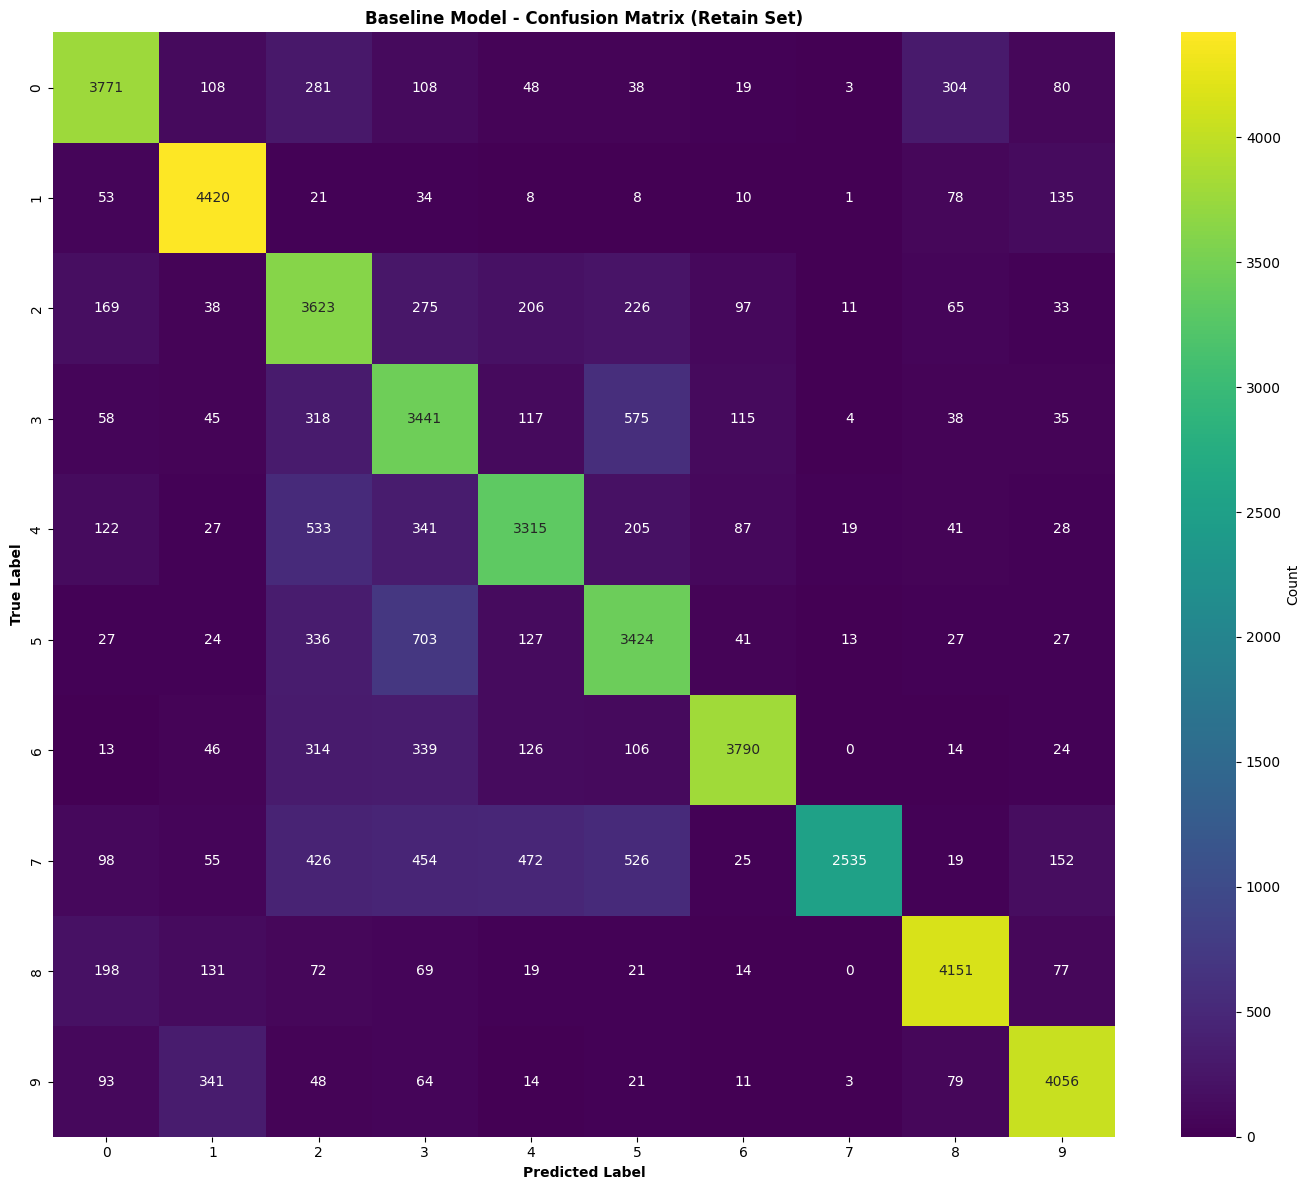

In [282]:
print("\n" + "="*70)
print("BASELINE MODEL - Per-Class Accuracy & Confusion Matrix")
print("="*70)

baseline_cm, baseline_per_class, _, _ = compute_confusion_matrix_and_per_class_metrics(
    baseline_full_model, retain_loader, device
)

# Display per-class accuracy
print("\nPer-Class Accuracy on RETAIN set:")
print("-" * 40)
for class_idx in range(10):
# for class_idx in range(100):
    acc = baseline_per_class[class_idx]
    if acc is not None:
        print(f"  Class {class_idx}: {acc:.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))
plot_confusion_matrix(baseline_cm, "Baseline Model - Confusion Matrix (Retain Set)", ax=ax)
plt.tight_layout()
save_plot(fig, "plot_01_baseline_confusion_matrix_retain.png")
plt.show()


UNLEARNED MODEL (First-Epoch Reversal) - Per-Class Accuracy & Confusion Matrix

Per-Class Accuracy on RETAIN set:
----------------------------------------
  Class 0: 0.8202
  Class 1: 0.8368
  Class 2: 0.5050
  Class 3: 0.7012
  Class 4: 0.7363
  Class 5: 0.5351
  Class 6: 0.7412
  Class 7: 0.8396
  Class 8: 0.7247
  Class 9: 0.7374
Saved plot: ../results/plots/CIFAR10_first_epoch_reversal_seed_0123_delete_0p05/plot_02_unlearned_confusion_matrix_retain.png


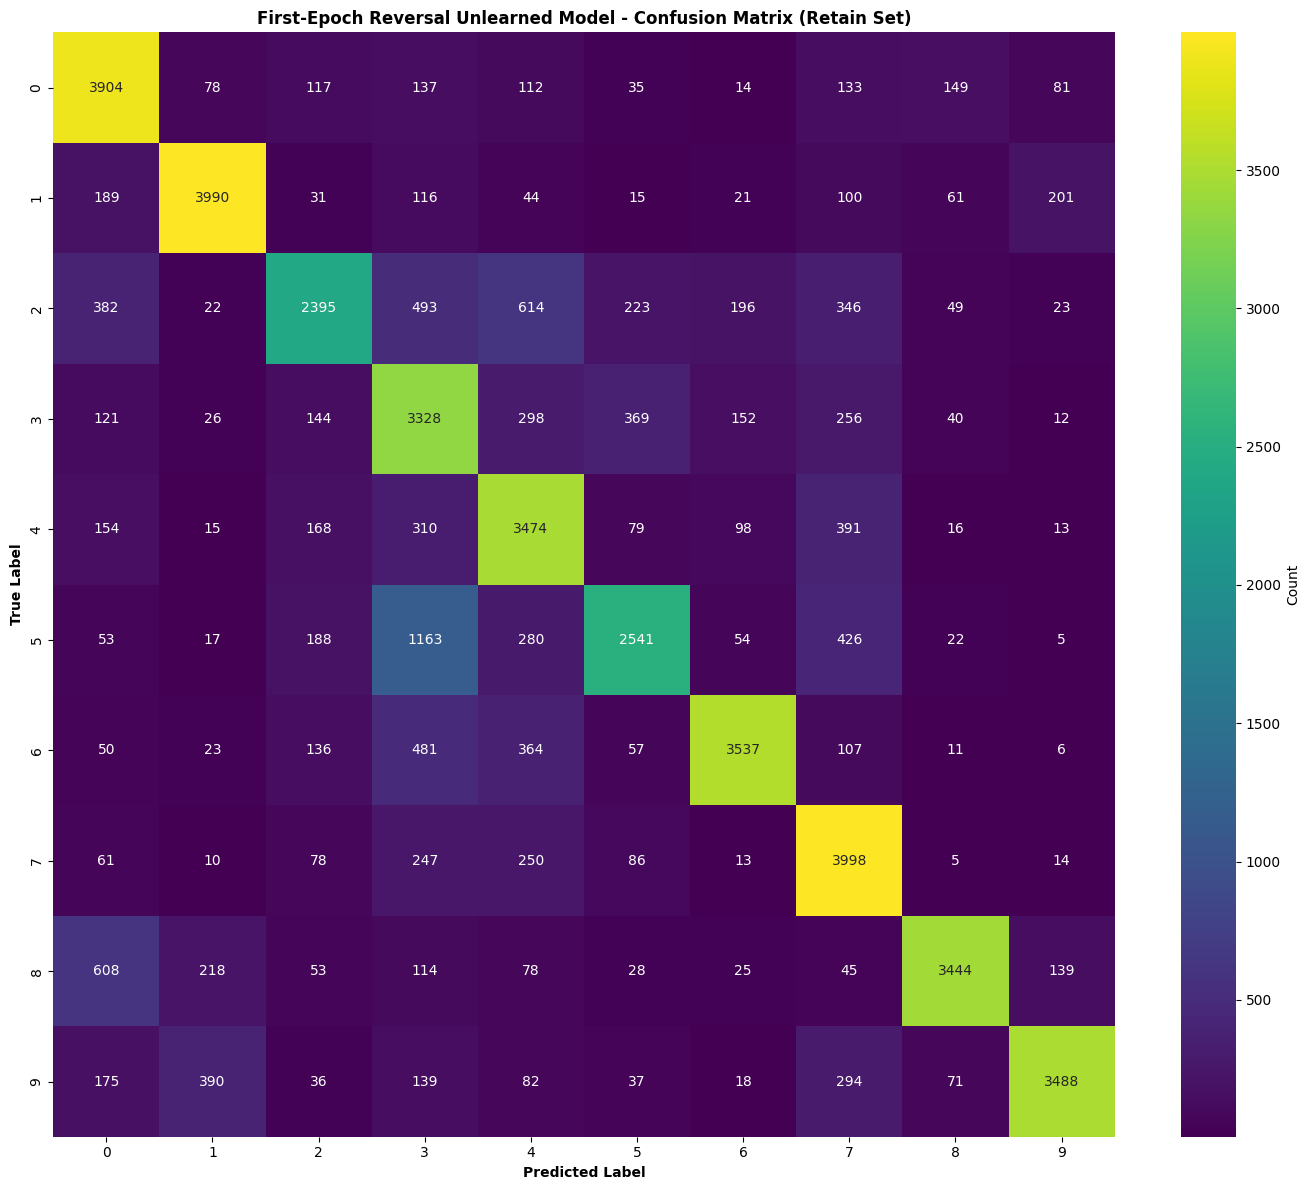

In [283]:
print("\n" + "="*70)
print("UNLEARNED MODEL (First-Epoch Reversal) - Per-Class Accuracy & Confusion Matrix")
print("="*70)

unlearned_cm, unlearned_per_class, _, _ = compute_confusion_matrix_and_per_class_metrics(
    unlearned_model, retain_loader, device
)

# Display per-class accuracy
print("\nPer-Class Accuracy on RETAIN set:")
print("-" * 40)
for class_idx in range(10):
# for class_idx in range(100):
    acc = unlearned_per_class[class_idx]
    if acc is not None:
        print(f"  Class {class_idx}: {acc:.4f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))
plot_confusion_matrix(unlearned_cm, "First-Epoch Reversal Unlearned Model - Confusion Matrix (Retain Set)", ax=ax)
plt.tight_layout()
save_plot(fig, "plot_02_unlearned_confusion_matrix_retain.png")
plt.show()

In [284]:
print("\n" + "="*70)
print("DELETE SET PERFORMANCE - Per-Class Accuracy")
print("="*70)
print("\nForgetting Score: How much baseline accuracy decreased per class")
print("(Higher = better forgetting)")

# Compute per-class metrics on DELETE set
baseline_delete_cm, baseline_delete_pc, _, _ = compute_confusion_matrix_and_per_class_metrics(
    baseline_full_model, delete_loader, device
)
unlearned_delete_cm, unlearned_delete_pc, _, _ = compute_confusion_matrix_and_per_class_metrics(
    unlearned_model, delete_loader, device
)

# Create comparison dataframe for DELETE set
delete_comparison_data = {
    'Class': list(range(10)),
    'Baseline (Before)': [baseline_delete_pc[d] for d in range(10)],
    'Unlearned (After)': [unlearned_delete_pc[d] for d in range(10)],
}

# delete_comparison_data = {
#     'Class': list(range(100)),
#     'Baseline (Before)': [baseline_delete_pc[d] for d in range(100)],
#     'Unlearned (After)': [unlearned_delete_pc[d] for d in range(100)],
# }

# Forgetting scores
delete_comparison_data['Forgetting Score'] = [
    (baseline_delete_pc[d] - unlearned_delete_pc[d])
    if baseline_delete_pc[d] is not None and unlearned_delete_pc[d] is not None
    else (baseline_delete_pc[d] if unlearned_delete_pc[d] is None else -unlearned_delete_pc[d])
    if baseline_delete_pc[d] is not None or unlearned_delete_pc[d] is not None
    else 0.0
    for d in range(10)
    # for d in range(100)
]

import pandas as pd
delete_comparison_df = pd.DataFrame(delete_comparison_data)
print("\n" + delete_comparison_df.to_string(index=False))

print("\n" + "="*70)
print("DELETE SET SUMMARY")
print("="*70)
print(f"\nAverage per-class accuracy on DELETE set:")
print(f"  Baseline (Before):     {delete_comparison_df['Baseline (Before)'].mean():.4f}")
print(f"  Unlearned (After):     {delete_comparison_df['Unlearned (After)'].mean():.4f}")

print(f"\nAverage Forgetting Score: {delete_comparison_df['Forgetting Score'].mean():.4f}")
print(f"\nBest Forgetting: Class {delete_comparison_df['Forgetting Score'].idxmax()} ({delete_comparison_df['Forgetting Score'].max():.4f})")
print(f"Worst Forgetting: Class {delete_comparison_df['Forgetting Score'].idxmin()} ({delete_comparison_df['Forgetting Score'].min():.4f})")


DELETE SET PERFORMANCE - Per-Class Accuracy

Forgetting Score: How much baseline accuracy decreased per class
(Higher = better forgetting)

 Class  Baseline (Before)  Unlearned (After)  Forgetting Score
     0           0.775000           0.741667          0.033333
     1           0.905172           0.706897          0.198276
     2           0.758755           0.431907          0.326848
     3           0.712598           0.519685          0.192913
     4           0.670213           0.631206          0.039007
     5           0.745020           0.458167          0.286853
     6           0.802632           0.684211          0.118421
     7           0.500000           0.739496         -0.239496
     8           0.879032           0.653226          0.225806
     9           0.855556           0.662963          0.192593

DELETE SET SUMMARY

Average per-class accuracy on DELETE set:
  Baseline (Before):     0.7604
  Unlearned (After):     0.6229

Average Forgetting Score: 0.1375

Best


CONFUSION MATRIX COMPARISON - Baseline vs Unlearned
Saved plot: ../results/plots/CIFAR10_first_epoch_reversal_seed_0123_delete_0p05/plot_03_confusion_matrix_comparison_retain.png


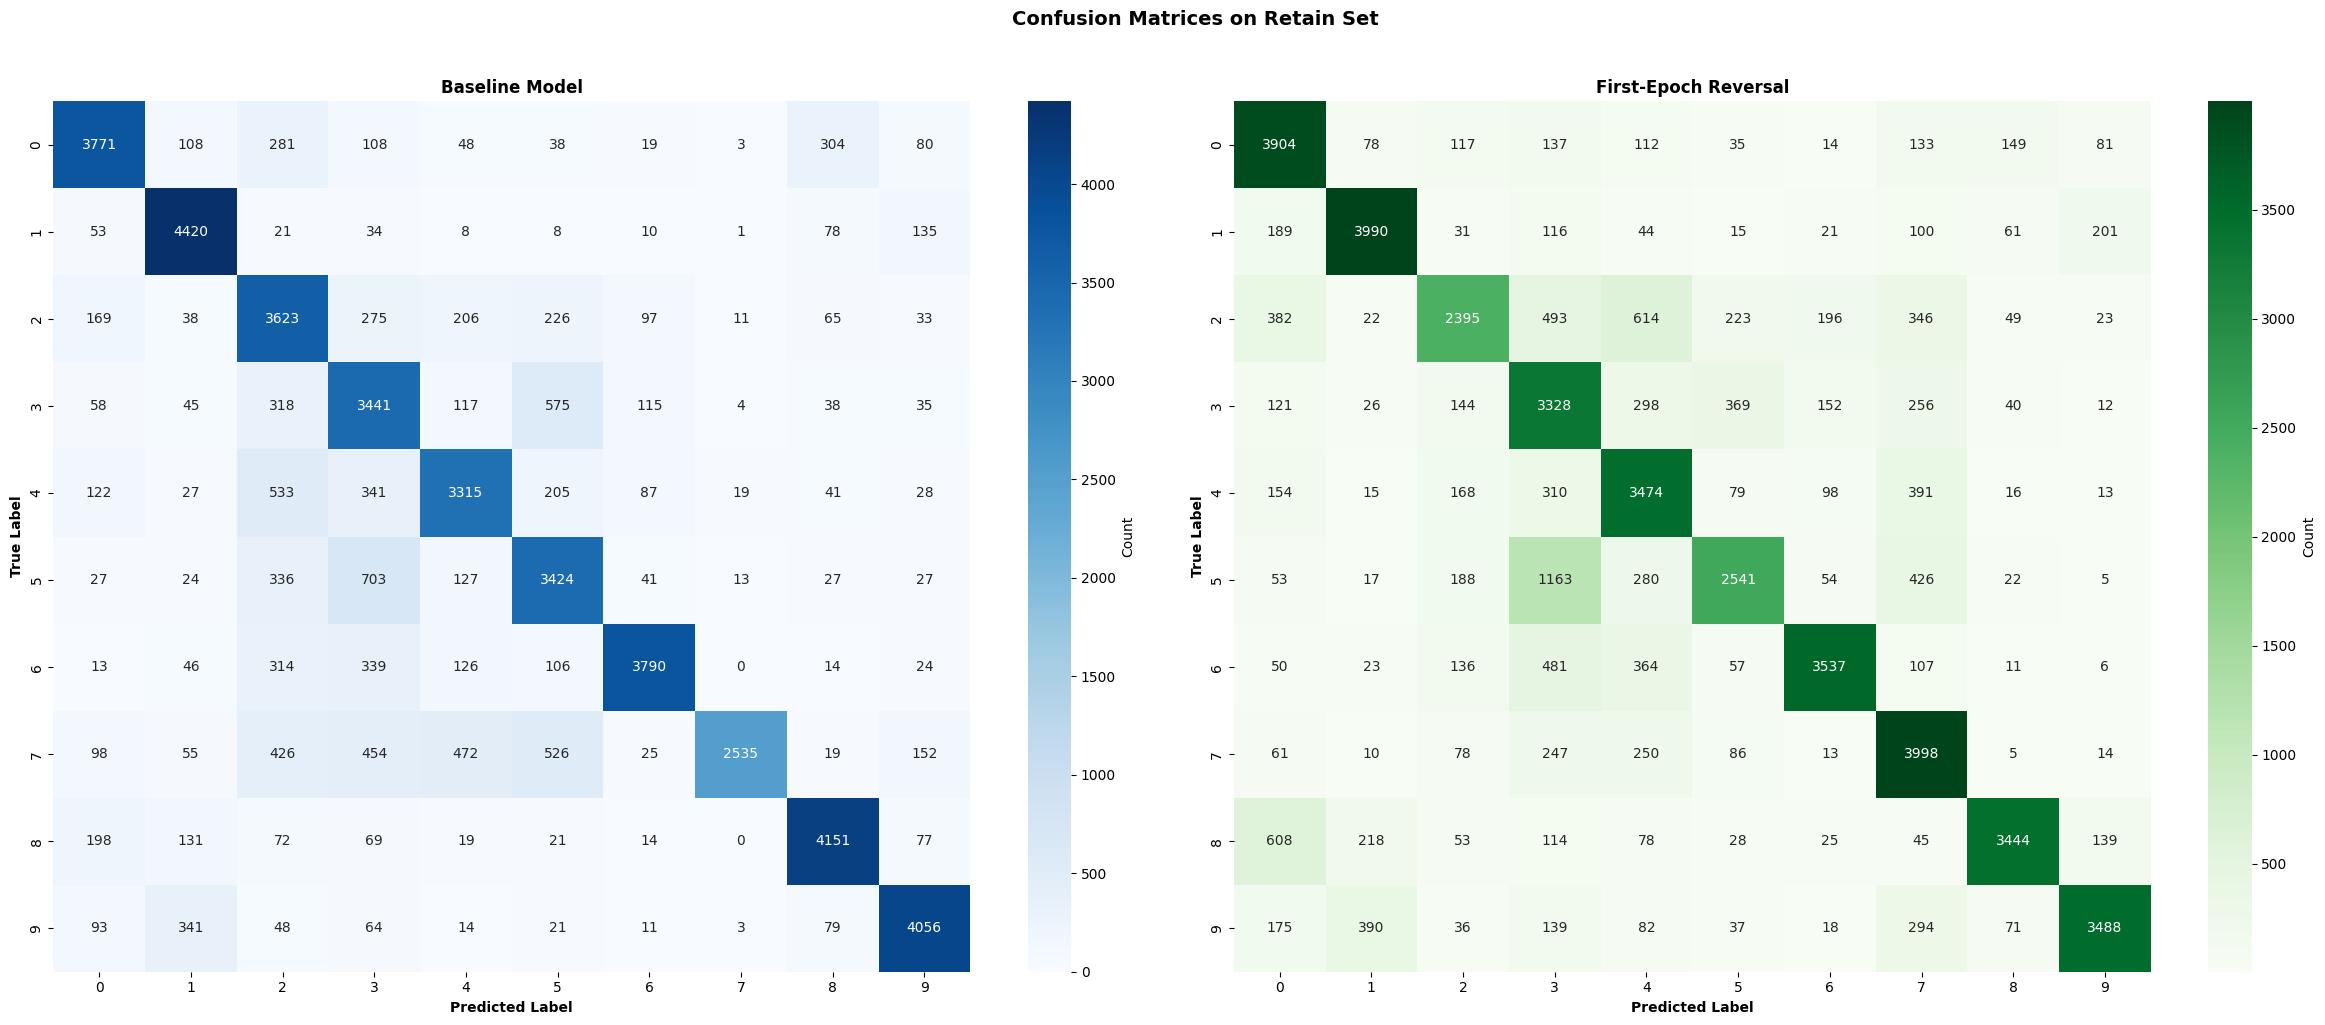

Confusion matrices visualized


In [285]:
print("\n" + "="*70)
print("CONFUSION MATRIX COMPARISON - Baseline vs Unlearned")
print("="*70)

# Create side-by-side confusion matrices (RETAIN set)
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

plot_confusion_matrix(baseline_cm, "Baseline Model", ax=axes[0], cmap='Blues')
plot_confusion_matrix(unlearned_cm, "First-Epoch Reversal", ax=axes[1], cmap='Greens')

plt.suptitle('Confusion Matrices on Retain Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_plot(fig, "plot_03_confusion_matrix_comparison_retain.png")
plt.show()

print("Confusion matrices visualized")


PER-CLASS ACCURACY VISUALIZATION (RETAIN SET)
Saved plot: ../results/plots/CIFAR10_first_epoch_reversal_seed_0123_delete_0p05/plot_04_per_class_accuracy_and_utility_loss.png


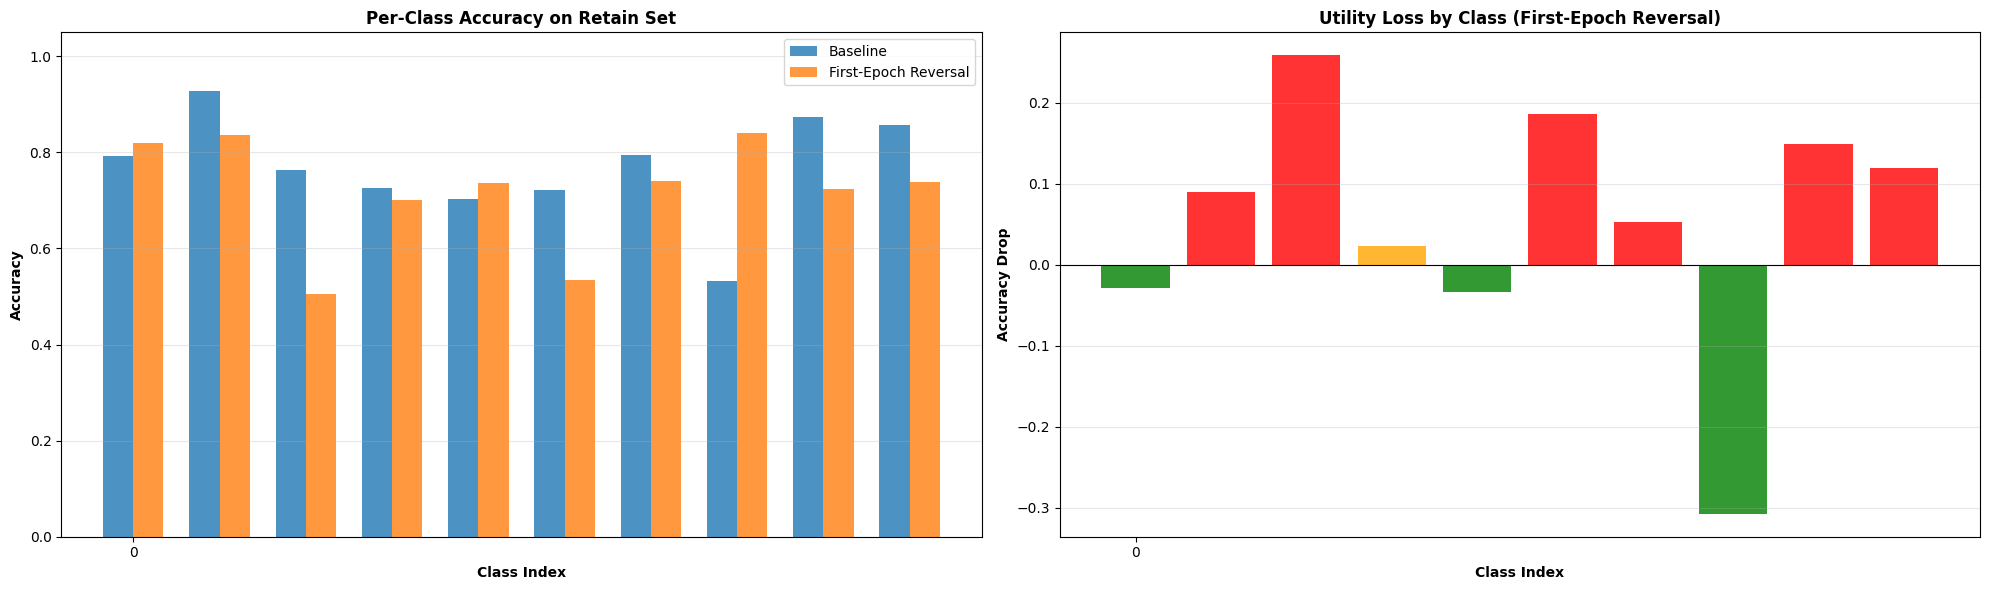

Per-class accuracy visualization complete


In [286]:
print("\nPER-CLASS ACCURACY VISUALIZATION (RETAIN SET)")

# Create bar chart comparing per-class accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot 1: Per-class accuracy for both methods
classes = list(range(10))
# classes = list(range(100))
x = np.arange(len(classes))
width = 0.35

baseline_accs = [baseline_per_class[d] for d in range(10)]
unlearned_accs = [unlearned_per_class[d] for d in range(10)]

# baseline_accs = [baseline_per_class[d] for d in range(100)]
# unlearned_accs = [unlearned_per_class[d] for d in range(100)]

ax1.bar(x - width/2, baseline_accs, width, label='Baseline', alpha=0.8)
ax1.bar(x + width/2, unlearned_accs, width, label='First-Epoch Reversal', alpha=0.8)

ax1.set_xlabel('Class Index', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Per-Class Accuracy on Retain Set', fontweight='bold')
# Show every 10th class label for readability
ax1.set_xticks(x[::10])
ax1.set_xticklabels(classes[::10])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.05])

# Plot 2: Utility Loss (how much each class dropped with unlearning)
utility_losses = [baseline_per_class[d] - unlearned_per_class[d] for d in range(10)]
# utility_losses = [baseline_per_class[d] - unlearned_per_class[d] for d in range(100)]
colors = ['red' if loss > 0.05 else 'orange' if loss > 0.02 else 'green' for loss in utility_losses]
ax2.bar(classes, utility_losses, color=colors, alpha=0.8)

ax2.set_xlabel('Class Index', fontweight='bold')
ax2.set_xticks(classes[::10])
ax2.set_ylabel('Accuracy Drop', fontweight='bold')
ax2.set_title('Utility Loss by Class (First-Epoch Reversal)', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
save_plot(fig, "plot_04_per_class_accuracy_and_utility_loss.png")
plt.show()

print("Per-class accuracy visualization complete")

In [287]:
# Load exact model for distance comparison
exact_model_path = f"../models/{DATASET_TAG}_gold_exact_seed_{SEED:04d}.pt"

if os.path.exists(exact_model_path):
    exact_model = SimpleCNN().to(device)
    exact_model.load_state_dict(torch.load(exact_model_path))
    exact_model.eval()
    print(f"Loaded exact model from: {exact_model_path}")
    
    # Calculate model distance metrics
    def model_distance_metrics(approx_model, exact_model):
        """Calculate L2 distance between two models."""
        sq_diff = 0.0
        sq_exact = 0.0
        
        for p_approx, p_exact in zip(approx_model.parameters(), exact_model.parameters()):
            sq_diff += torch.sum((p_approx - p_exact) ** 2)
            sq_exact += torch.sum(p_exact ** 2)
        
        abs_dist = torch.sqrt(sq_diff).item()
        norm_exact = torch.sqrt(sq_exact).item()
        rel_dist = abs_dist / (norm_exact + 1e-12)
        
        return abs_dist, rel_dist
    
    abs_l2, rel_l2 = model_distance_metrics(unlearned_model, exact_model)
    print(f"\nModel Distance Metrics:")
    print(f"  Absolute L2 Distance: {abs_l2:.4f}")
    print(f"  Relative L2 Distance: {rel_l2:.4%}")
else:
    print(f"✗ Exact model not found at {exact_model_path}")
    abs_l2 = None
    rel_l2 = None


Loaded exact model from: ../models/CIFAR10_gold_exact_seed_0123.pt

Model Distance Metrics:
  Absolute L2 Distance: 31.7606
  Relative L2 Distance: 110.7128%


In [288]:
# Prepare comprehensive results
def _to_float_or_none(v):
    return None if v is None else float(v)

def _diff_or_none(a, b):
    return None if a is None or b is None else float(a - b)

results = {
    "experiment_info": {
        "timestamp": datetime.now().isoformat(),
        "dataset": DATASET_TAG,
        "model": "SimpleCNN",
        "deletion_ratio": DELETE_RATIO,
        "device": device,
        "seed": SEED
    },

    "first_epoch_reversal": {
        "method": "first_epoch_reversal",
        "description": "Revert to early checkpoint and retrain on retain set",
        "hyperparameters": {
            "rewind_epoch": train_meta["save_epoch"],
            "total_training_epochs": train_meta["total_epochs"],
            "retrain_epochs": RETRAIN_EPOCHS,
            "optimizer": "Adam",
            "learning_rate": LEARNING_RATE,
            "batch_size": BATCH_SIZE,
            "loss_function": LOSS_NAME
        },
        "metrics": {
            "deleted_loss": float(delete_metrics["loss"]),
            "deleted_accuracy": float(delete_metrics["accuracy"]),
            "retained_loss": float(retain_metrics["loss"]),
            "retained_accuracy": float(retain_metrics["accuracy"])
        },
        "per_class_accuracy": {
            "retain_set": {str(i): _to_float_or_none(unlearned_per_class.get(i)) for i in range(NUM_CLASSES)},
            "delete_set": {str(i): _to_float_or_none(unlearned_delete_pc.get(i)) for i in range(NUM_CLASSES)},
        },
        "per_class_forgetting_score": {
            str(i): _diff_or_none(baseline_delete_pc.get(i), unlearned_delete_pc.get(i))
            for i in range(NUM_CLASSES)
        },
        "per_class_utility_loss": {
            str(i): _diff_or_none(baseline_per_class.get(i), unlearned_per_class.get(i))
            for i in range(NUM_CLASSES)
        },
        "time_seconds": float(unlearn_time),
        "distance_metrics": {
            "l2_absolute": float(abs_l2) if abs_l2 is not None else None,
            "l2_relative": float(rel_l2) if rel_l2 is not None else None,
            "metric_definition": "L2 distance from exact retrained model (gold standard)"
        }
    },
    
    "baseline_model": {
        "method": "baseline_trained_on_all_data",
        "description": "Model trained on all data (for MIA comparison)",
        "metrics": {
            "deleted_loss": float(baseline_delete_metrics["loss"]),
            "deleted_accuracy": float(baseline_delete_metrics["accuracy"]),
            "retained_loss": float(baseline_retain_metrics["loss"]),
            "retained_accuracy": float(baseline_retain_metrics["accuracy"])
        },
        "per_class_accuracy": {
            "retain_set": {str(i): _to_float_or_none(baseline_per_class.get(i)) for i in range(NUM_CLASSES)},
            "delete_set": {str(i): _to_float_or_none(baseline_delete_pc.get(i)) for i in range(NUM_CLASSES)},
        }
    },
    
    "privacy_evaluation": {
        "method": "membership_inference_attack",
        "mia_baseline": {
            "mia_accuracy": float(mia_baseline["mia_accuracy"]),
            "tpr": float(mia_baseline["tpr"]),
            "fpr": float(mia_baseline["fpr"]),
            "auc_roc": _to_float_or_none(mia_baseline.get("auc_roc"))
        },
        "mia_unlearned": {
            "mia_accuracy": float(mia_unlearned["mia_accuracy"]),
            "tpr": float(mia_unlearned["tpr"]),
            "fpr": float(mia_unlearned["fpr"]),
            "auc_roc": _to_float_or_none(mia_unlearned.get("auc_roc"))
        },
        "privacy_improvement": float(mia_baseline["mia_accuracy"] - mia_unlearned["mia_accuracy"])
    },
    
    "saved_models": {
        "baseline_checkpoint": train_meta["checkpoint_path"],
        "baseline_full": train_meta["full_model_path"],
        "unlearned_model": unlearned_path
    }
}

print("\nResults dictionary prepared")


Results dictionary prepared


In [289]:
# Save results to JSON with formatted delete ratio
os.makedirs("../results/metadata", exist_ok=True)
delete_ratio_formatted = f"{DELETE_RATIO:.4f}".rstrip("0").rstrip(".").replace(".", "p")
filename = f"../results/metadata/{DATASET_TAG}_first_epoch_reversal_seed_{SEED:04d}_{delete_ratio_formatted}_results.json"

with open(filename, "w") as f:
    json.dump(results, f, indent=4)

print(f"\n{'='*50}")
print("RESULTS SAVED")
print(f"{'='*50}")
print(f"✓ Results JSON: {filename}")
print(f"✓ Baseline checkpoint: {train_meta['checkpoint_path']}")
print(f"✓ Baseline full model: {train_meta['full_model_path']}")
print(f"✓ Unlearned model: {unlearned_path}")


RESULTS SAVED
✓ Results JSON: ../results/metadata/CIFAR10_first_epoch_reversal_seed_0123_0p05_results.json
✓ Baseline checkpoint: ../models/CIFAR10_early_checkpoint_seed_0123_epoch0.pt
✓ Baseline full model: ../models/CIFAR10_full_model_seed_0123.pt
✓ Unlearned model: ../models/CIFAR10_reversal_unlearned_seed_0123.pt
